In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
from Trainer import Trainer, evaluate_model
from util import show_dataset_prev
from GenericDatasetReader import get_datasets

#Clone the repository: #https://github.com/LeeJunHyun/Image_Segmentation/blob/master/network.py
#Add the clone location to be able to import from UNets
#The training of these networks was done in colab, so it will be necessary to adapt this script for execution
sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
from network import U_Net
from network import AttU_Net
from network import R2AttU_Net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './colab_unets/'

In [2]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 1

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size)

torch.Size([16, 3, 224, 224]) torch.Size([16, 1, 224, 224])
8701 97 98


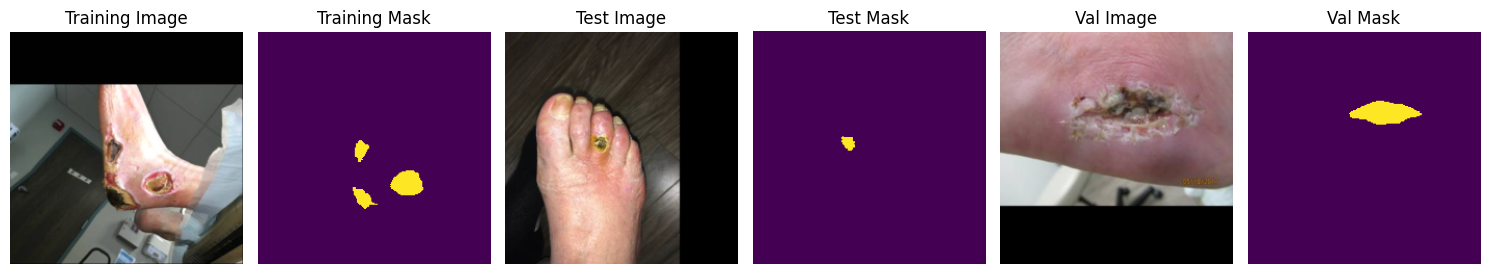

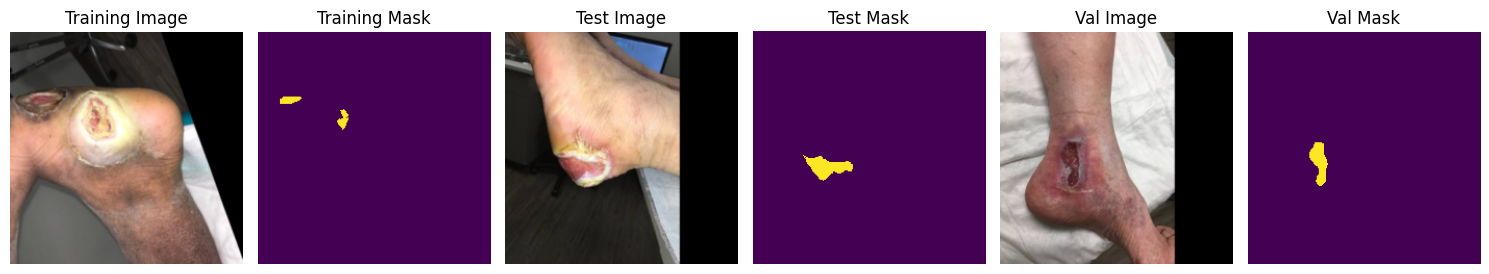

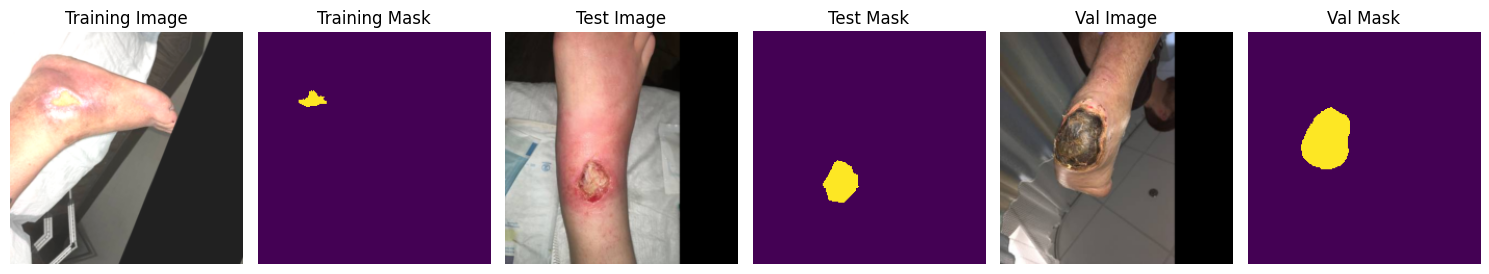

In [3]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3)

In [ ]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



In [7]:
# Here we will load the model weights that were trained in colab
def load_and_evaluate_model(model, test_loader, model_name=None):
    model_filename = f'{result_path}/{model_name}-epochs300-best.pth'
    state_dict = torch.load(model_filename, map_location='cpu')
    model.load_state_dict(state_dict['model_state_dict'], strict=False)
    model.to('cuda')
    stats_best = evaluate_model(model, test_loader, print_stats=True)

    model_filename = f'{result_path}/{model_name}-epochs300-last.pth'
    state_dict = torch.load(model_filename, map_location='cpu')
    model.load_state_dict(state_dict['model_state_dict'], strict=False)
    model.to('cuda')
    stats_last = evaluate_model(model, test_loader, print_stats=True)

    if stats_best['f1'] > stats_last['f1']:
        return stats_best
    else:
        return stats_last

In [8]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'UNet-1')
stats1 = load_and_evaluate_model(model, test_loader, 'UNet-1')

Loss: 0.0000 F1: 0.9549 mIoU: 0.9174 Prec: 0.9559 Recall: 0.9544 Q: 0.8762
Loss: 0.0000 F1: 0.9514 mIoU: 0.9119 Prec: 0.9482 Recall: 0.9552 Q: 0.8680


In [9]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'UNet-2')
stats2 = load_and_evaluate_model(model, test_loader, 'UNet-2')

Loss: 0.0000 F1: 0.9583 mIoU: 0.9234 Prec: 0.9595 Recall: 0.9575 Q: 0.8852
Loss: 0.0000 F1: 0.9575 mIoU: 0.9220 Prec: 0.9584 Recall: 0.9570 Q: 0.8831


In [10]:
model = U_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'UNet-3')
stats3 = load_and_evaluate_model(model, test_loader, 'UNet-3')

Loss: 0.0000 F1: 0.9512 mIoU: 0.9118 Prec: 0.9545 Recall: 0.9484 Q: 0.8678
Loss: 0.0000 F1: 0.9550 mIoU: 0.9176 Prec: 0.9590 Recall: 0.9515 Q: 0.8764


In [11]:
print("U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

U-Net
AVG F1-Score: 0.956
Max F1-Score: 0.958
AVG mIoU: 0.919
AVG mIoU: 0.923


In [12]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'AttU_Net-1')
stats1 = load_and_evaluate_model(model, test_loader, 'AttU_Net-1')

Loss: 0.0000 F1: 0.9454 mIoU: 0.9021 Prec: 0.9542 Recall: 0.9375 Q: 0.8533
Loss: 0.0000 F1: 0.9520 mIoU: 0.9124 Prec: 0.9650 Recall: 0.9403 Q: 0.8687


In [13]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'AttU_Net-2')
stats2 = load_and_evaluate_model(model, test_loader, 'AttU_Net-2')

Loss: 0.0000 F1: 0.9551 mIoU: 0.9180 Prec: 0.9556 Recall: 0.9552 Q: 0.8771
Loss: 0.0000 F1: 0.9547 mIoU: 0.9172 Prec: 0.9578 Recall: 0.9522 Q: 0.8759


In [14]:
model = AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'AttU_Net-3')
stats3 = load_and_evaluate_model(model, test_loader, 'AttU_Net-3')

Loss: 0.0000 F1: 0.9524 mIoU: 0.9134 Prec: 0.9555 Recall: 0.9501 Q: 0.8702
Loss: 0.0000 F1: 0.9560 mIoU: 0.9193 Prec: 0.9631 Recall: 0.9497 Q: 0.8790


In [15]:
print("Attention U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

Attention U-Net
AVG F1-Score: 0.954
Max F1-Score: 0.956
AVG mIoU: 0.917
AVG mIoU: 0.919


In [16]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats1 = train(model,'R2AttU_Net-1')
stats1 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-1')

Loss: 0.0000 F1: 0.9312 mIoU: 0.8797 Prec: 0.9130 Recall: 0.9538 Q: 0.8198
Loss: 0.0000 F1: 0.9325 mIoU: 0.8813 Prec: 0.9560 Recall: 0.9132 Q: 0.8221


In [17]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats2 = train(model,'R2AttU_Net-2')
stats2 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-2')

Loss: 0.0000 F1: 0.9366 mIoU: 0.8878 Prec: 0.9566 Recall: 0.9199 Q: 0.8319
Loss: 0.0000 F1: 0.9148 mIoU: 0.8551 Prec: 0.9776 Recall: 0.8682 Q: 0.7830


In [18]:
model = R2AttU_Net(img_ch=in_channels, output_ch=out_channels)
#stats3 = train(model,'R2AttU_Net-3')
stats3 = load_and_evaluate_model(model, test_loader, 'R2AttU_Net-3')

Loss: 0.0000 F1: 0.9366 mIoU: 0.8879 Prec: 0.9554 Recall: 0.9208 Q: 0.8320
Loss: 0.0000 F1: 0.9103 mIoU: 0.8481 Prec: 0.9795 Recall: 0.8594 Q: 0.7724


In [19]:
print("Recurrent Attention U-Net")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

Recurrent Attention U-Net
AVG F1-Score: 0.935
Max F1-Score: 0.937
AVG mIoU: 0.886
AVG mIoU: 0.888
